# Анализ данных на Python

*Алла Тамбовцева*

## Линейная регрессия и ее расширения

Импортируем все необходимые библиотеки и функции:
    
* библиотеки `pandas` и `numpy` для обработки данных;
* библиотека `seaborn` для графики (надстройка над `matplotlib`);
* функция `ols` из подмодуля `formula.api` библиотеки `statsmodels`.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from statsmodels.formula.api import ols

/opt/anaconda3/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


В этом практикуме будем работать с файлом `salaries.csv`. Показатели в файле:

В этом файле сохранены данные по сотрудникам университета в США, а именно следующие их характеристики:

* `rank`: должность;
* `discipline`: тип преподаваемой дисциплины (`A` – теоретическая, `B` – практическая);
* `phd`: число лет с момента получения степени PhD;
* `service`: число лет опыта работы;
* `sex`: пол;
* `salary`: заработная плата за 9 месяцев, в долларах.

Загружаем данные:

In [2]:
dat = pd.read_csv("https://raw.githubusercontent.com/allatambov/PyPerm25/refs/heads/main/salaries.csv")
dat.head()

,Unnamed: 0,rank,discipline,phd,service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


Посмотрим на описательные статистики для числовых столбцов:

In [3]:
dat.describe()

,Unnamed: 0,phd,service,salary
count,397.000000,397.000000,397.000000,397.000000
mean,199.000000,22.314861,17.614610,113706.458438
std,114.748275,12.887003,13.006024,30289.038695
min,1.000000,1.000000,0.000000,57800.000000
25%,100.000000,12.000000,7.000000,91000.000000
50%,199.000000,21.000000,16.000000,107300.000000
75%,298.000000,32.000000,27.000000,134185.000000
max,397.000000,56.000000,60.000000,231545.000000


Не будем подробно их обсуждать, просто обратим внимание на существенные различия среднего и медианы, а также верхнего квартиля и максимума по столбцу `salary`. Распределение заработной платы скошено вправо, есть нехарактерно большие значения. 

## Множественная линейная регрессия: интерпретация результатов

Пока пренебрежем этим и построим обычную множественную линейную регрессию, которая будет предсказывать значение заработной платы в зависимости от следующих факторов:

* `service`: стаж;
* `phd`: число лет с момента получения кандидатской степени;
* `sex`: пол;
* `discipline`: тип преподаваемой дисциплины.

In [4]:
# особенность функций в formula.api: записываем уравнение через ~
# .fit() для оценки модели, .summary() для выдачи с результатами

m01 = ols("salary ~ service + phd + sex + discipline", data = dat).fit()
print(m01.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     35.04
Date:                Thu, 19 Jun 2025   Prob (F-statistic):           5.06e-25
Time:                        01:35:54   Log-Likelihood:                -4598.6
No. Observations:                 397   AIC:                             9207.
Df Residuals:                     392   BIC:                             9227.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        7.133e+04   4981.841     

Сфокусируемся на центральной части выдачи:
    
    ===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
    -----------------------------------------------------------------------------------
    Intercept        7.133e+04   4981.841     14.317      0.000    6.15e+04    8.11e+04
    sex[T.Male]      7545.3126   4462.598      1.691      0.092   -1228.307    1.63e+04
    discipline[T.B]  1.633e+04   2708.903      6.027      0.000     1.1e+04    2.17e+04
    service          -770.0999    244.106     -3.155      0.002   -1250.020    -290.179
    phd              1804.1452    248.867      7.249      0.000    1314.863    2293.427
    ==============================================================================

Если в модель добавляются текстовые переменные, `ols()` автоматически разбивает их на набор бинарных столбцов (*one-hot encoding*), и во избежание строгой линейной зависимости (мультиколлинеарности) в модель включает не все бинарные столбцы, а на один меньше. Категория, соответствующая единицам в бинарном столбце, не включенном в модель, считается *базовой*. По умолчанию базовая категория – первая по алфавиту в исходном текстовом столбце. В данном случае значения в `sex` были `Female` и `Male`,  соответственно, были созданы бинарные столбцы `Female` и `Male`, категория `Female` стала базовой, а бинарный столбец `Male` был включен в модель. Отсюда `sex[T.Male]` в выдаче, `T.Male` расшифровывается как `True` для `Male`. Аналогичная история с типом дисциплины.

Запишем уравнение модели. Для этого вызовем коэффициенты отдельно, чтобы они показывались в более приятном виде, чем в столбце `coef`:

In [5]:
# атрибут .params
# параметры модели – как параметры оцениваемой функции

print(m01.params)

Intercept          71325.789934
sex[T.Male]         7545.312638
discipline[T.B]    16325.417707
service             -770.099929
phd                 1804.145169
dtype: float64


Уравнение модели (коэффициенты округлены до целых):

$$
\widehat{salary}_i = 71326 + 7545 \cdot \text{sex[T.Male]} + 16325 \cdot \text{discipline[T.B]} - 770 \cdot \text{service} + 1804 \cdot \text{phd}
$$

Проинтерпретируем коэффициенты – пока не обращаем внимание на их значимость:

* Константа `Intercept` – среднее ожидаемое значение зависимой переменной, когда все независимые равны 0. Часто такое равенство 0 на практике недостижимо, поэтому константа не является интерпретируемой, однако здесь другой случай. Если `sex[T.Male]`, `discipline[T.B]`, `service`, `phd` равны 0, это означает, что мы предсказываем заработную плату для женщины, преподающей теоретическую дисциплину, с нулевым стажем и только-только получившей степень. И средняя заработная плата таких сотрудников, согласно модели, равна 71326 долларов (это за 9 месяцев работы).

* При прочих равных условиях (если мы рассматриваем сотрудников одинакового пола, преподающих один и тот же тип дисциплины и с одинаковым опытом работы) при увеличении числа лет после получения степени на 1 год, заработная плата, в среднем, увеличивается на 1804 доллара.

* При прочих равных условиях (если мы рассматриваем сотрудников одинакового пола, преподающих один и тот же тип дисциплины и с одинаковым числом лет после получения степени) при увеличении стажа на 1 год, заработная плата, в среднем, уменьшается на 770 долларов. Почему такой нелогичный результат? Скорее всего, зависимость между стажем и заработной платой нелинейная и немонотонная. До какого-то момента опыт работы «увеличивает» заработную плату, а потом – наоборот. На самом деле, здесь так и есть, чуть позже остановимся на этом поподробнее.

* При прочих равных условиях средняя заработная плата мужчин выше на 7545 долларов, чем средняя заработная плата женщин. При прочих равных условиях средняя заработная плата преподавателей-практиков выше на 16325, чем заработная плата преподавателей-теоретиков. Коэффициент при бинарной переменной разумно интерпретировать как разницу средних, поскольку никакого увеличения на 1 содержательно произойти не может. 


Чтобы проверить статистическую значимость коэффициентов и понять, если ли значимый эффект независимых переменных на заработную плату, нужно проверить нулевую гипотезу следующего вида:

$$
H_0: b_j = 0 \text{ против } H_1: b_j \ne 0,
$$

где $b_j$ – теоретическое значение коэффициента при j-той независимой переменной.

Можем вычислить наблюдаемое значение статистики критерия, используемого для проверки этой гипотезы. Оно получается делением оценки коэффициента $\hat{b_j}$ на его стандартную ошибку (оценку стандартного отклонения).

$$
t_{набл} = \frac{\hat{b_j}}{\hat{\sigma}_{\hat{b_j}}} = \frac{\hat{b_j}}{se(\hat{b_j})} = \frac{\text{coef}}{\text{std err}}
$$

В таблице выше $t_{набл}$ – это значение в столбце `t`. Как можно заметить, его, действительно, можно получить, поделив, например, коэффициент 7545.3126 в `coef` на стандартную ошибку 4462.598 в `std err` (у константы то же самое, просто нас она не интересует). Итак, $t_{набл} = 1.691$. Если нулевая гипотеза верна, то $\hat{b}_1$ имеет распределение Стьюдента с числом степеней свободы $\text{df} = n-k$, где $n$ – число наблюдений, $k$ – число переменных, включая зависимую. Здесь $\text{df}=397-5=392$. Так как число степеней свободы велико, такое распределение Стьюдента практически не отличается от стандартного нормального. Поэтому, если мы примем уровень доверия равным 95%, область достоверных значений статистики будет включать значения примерно от -2 до 2. Здесь наблюдаемое значение 1.691, оно не попадает в критическую область, гипотеза не отвергается. А значит, эффект пола на зарплату нулевой, значение 7545 получилось случайно.

Конечно, на практике чаще всего не строят критическую область «в уме», а просто смотрят на p-value как на показатель жизнеспособности нулевой гипотезы с учётом имеющихся данных. Здесь p-value находится в столбце `P>|t|`, название столбца как раз отражает его смысл, так как

$$
\text{p-value} = \text{P}(|t| > |t_{набл}|) = \text{P}(t > 1.691) + \text{P}(t < -1.691).
$$

Python самостоятельно посчитал эту вероятность, p-value равно 0.092 При 95% уровне доверия (уровне значимости 5%) нулевая гипотеза не отвергается, так как p-value более 0.05.

Остальные коэффициенты можно считать статистически значимыми на уровне значимости 5%, а значит, значимо отличными от 0 (все p-value = 0). 

Альтернативный способ проверки гипотезы о коэффициенте – посмотреть на доверительный интервал для него. Если доверительный интервал содержит 0, то на выбранном уровне доверия гипотеза о равенстве коэффициента 0 не отвергается, эффекта нет. В выдаче по умолчанию указывается стандартный 95%-ный доверительный интервал, поэтому последний столбец в выдаче выглядит как `[0.025 0.975]`. Здесь тоже можно заметить, что доверительные интервалы для всех коэффициентов, кроме коэффициента при поле, не включают 0.

В случае множественной модели любопытно посмотреть и на значения `F-statistic` и `Prob (F-statistic)` из верхней части выдачи:

    ==============================================================================
    Dep. Variable:                 salary   R-squared:                       0.263
    Model:                            OLS   Adj. R-squared:                  0.256
    Method:                 Least Squares   F-statistic:                     35.04
    Date:                Wed, 18 Jun 2025   Prob (F-statistic):           5.06e-25
    Time:                        23:10:35   Log-Likelihood:                -4598.6
    No. Observations:                 397   AIC:                             9207.
    Df Residuals:                     392   BIC:                             9227.
    Df Model:                           4                                         
    Covariance Type:            nonrobust                                         
    ===================================================================================
    
    
Помимо гипотез для отдельных коэффициентов проверяется следующее:

$$
H_0: b_1 = b_2 = b_3 = \dots = 0 \text{ против } H_1:\exists j \text{ } b_j \ne 0
$$

Другими словами, проверяется гипотеза о том, что модель бесполезна :) Если все коэффициенты равны 0 (константа не в счет), то предсказание с помощью модели ничем не лучше вычисления среднего арифметического для зависимой переменной. Значение статистики критерия для проверки такой гипотезы принадлежит F-распределению Фишера, поэтому здесь считается F-наблюдаемое и соответствующее p-value. 

Кроме того, в этой части выдачи указан $R^2$, коэффициент детерминации `R-squared`, метрика, которая показывает, какую долю дисперсии зависимой переменной объясняет модель. Здесь эта доля небольшая, 26%. Рядом указано значение скорректированной метрики – `Adj. R-squared`, вариант коэффициента с поправкой на число переменных в модели (можно почитать [здесь](https://en.wikipedia.org/wiki/Coefficient_of_determination)).

Краткие комментарии по оставшимся фрагментам этой части выдачи:

* `No. Observations`: число наблюдений;
* `Df Residuals`: число степеней свободы для распределения остатков модели;
* `Df Model`: число степеней свободы для распределения объясненной суммы квадратов;
* `Log-Likelihood`: логарим функции правдоподобия модели; сам по себе не интерпретируется, но его можно сравнивать для разных моделей, чем выше, тем лучше качество модели;
* `AIC` и `BIC` – информационные критерии Акаике и Байеса; так как они включают в себя логарифм правдоподобия модели со знаком минус, чем ниже их значения, тем лучше качество модели; `AIC` и `BIC` нет смысла сравнивать между собой, нужно сравнивать соответствующие метрики у разных моделей с *одинаковой зависимой переменной*.

## Множественная линейная регрессия: улучшаем модель

Вернемся к описательным статистикам. Мы отметили, что распределение заработной платы скошено вправо, плюс, разброс значений велик. Это может негативно сказываться на качестве модели, поэтому избавимся от такого большого разброса в данных, сохраняя порядок значений – логарифмируем столбец `salary`:

In [6]:
dat["lsalary"] = np.log(dat["salary"])

Построим новую модель:

In [7]:
m01 = ols("lsalary ~ service + phd + sex + discipline", data = dat).fit()
print(m01.summary())

                            OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.273
Method:                 Least Squares   F-statistic:                     38.16
Date:                Thu, 19 Jun 2025   Prob (F-statistic):           5.70e-27
Time:                        01:36:30   Log-Likelihood:                 36.973
No. Observations:                 397   AIC:                            -63.95
Df Residuals:                     392   BIC:                            -44.03
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          11.2273      0.042    2

Модель немного изменилась, изменились и коэффициенты и p-value, плюс, $R^2$ немного увеличился. Интерпретировать коэффициенты сейчас менее удобно, придется описывать изменении логарифма заработной платы, но это нестрашно, поскольку часто нам достаточно знака и значимости. 

Как еще улучшить качество модели с точки зрения выполнения разных допущений (выполнение допущений не означает более высокий $R^2$)? Например, проверить, что независимые переменные не связаны друг с другом сильной линейной связью. Если такое наблюдается, имеет место проблема мультиколлинеарности, что может привести к искусственно завышенным значениям стандартных ошибок коэффициентов, как следствие, к заниженным значениям t-статистик, а значит, к более высоким p-value. Из-за этого ошибочно коэффициенты модели могут оказаться незначимыми, хотя они на самом деле отличны от 0. При этом $R^2$ у таких моделей обычно очень высокий, так как сильная линейная связь независимых переменных «раздувает» значения совокупной дисперсии (вспомните свойства дисперсии в случае, если величины не независимы).

Вычислим коэффициент корреляции Пирсона между двумя числовыми независимыми переменными в модели:

In [8]:
dat[["service", "phd"]].corr()

,service,phd
service,1.000000,0.909649
phd,0.909649,1.000000


Коэффициент достаточно высокий, 0.9. Как быть? Самое простое решение – избавиться от «дублирования» информации и оставить в модели только одну из переменных. Более сложное решение – через методы снижения размерности подобрать веса для переменных и в модель включить линейную комбинацию этих переменных – новую переменную как интегральный индекс от двух старых. Мы пойдем по первому пути и оставим в модели только `phd` (если оставим `service`, $R^2$ будет ниже, можете проверить):

In [9]:
m02 = ols("lsalary ~ phd + sex + discipline", data = dat).fit()
print(m02.summary())

                            OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     46.39
Date:                Thu, 19 Jun 2025   Prob (F-statistic):           1.10e-25
Time:                        01:36:40   Log-Likelihood:                 31.870
No. Observations:                 397   AIC:                            -55.74
Df Residuals:                     393   BIC:                            -39.80
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          11.2549      0.042    2

Выполнения одного из требований к модели мы достигли, однако $R^2$ логичным образом сейчас упал. Давайте подумаем, какие особенности данных мы еще не учли. 

В модели осталась только одна количественная переменная (отсюда, кстати, и снижение $R^2$, дисперсия бинарных показателей по определению маленькая, они не могут сильно увеличить часть дисперсии зависимой переменной, объясненнной моделью), посмотрим на характер ее связи с заработной платой. Построим диаграмму рассеивания с добавленной на нее регрессионной прямой через функцию `lmplot()` из `seaborn`:

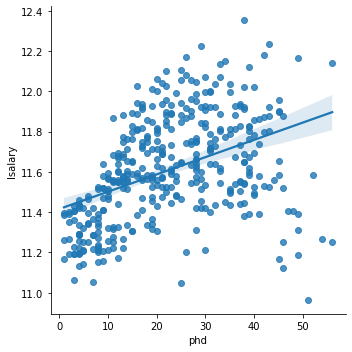

In [10]:
# lmplot: linear model plot
# парная модель lsalary ~ phd
# на график добавляется 95%-ный доверительный интервал для прямой

sns.lmplot(data = dat, x = "phd", y = "lsalary");

Что тут видно? Прямая, в целом, проходит через облако точек, однако связь больше похожа на нелинейную. А точнее, на квадратичную, на растянутую параболу с ветвями вниз. Проверим свои догадки и с помощью другой функции `regplot()` и укажем, что хотим оценить взаимосвязь через многочлен второй степени (`order = 2`):

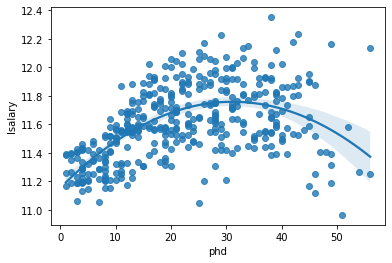

In [11]:
# regplot: regression model plot,
# не только линейные модели

sns.regplot(data = dat, x = "phd", y = "lsalary", order = 2);

Вот тут уже получше. Однако коэффициенты в квадратичной модели чуть менее приятно интерпретировать, плюс, нам надо вернуться к исходной модели, где также есть пол и тип дисциплины, а с этими факторами квадратичная функция уже не увязывается. Как учесть квадратичную зависимость в рамках *линейной модели*? Добавить переменную в квадрате, но не предварительно возведя значения в столбце в квадрат, а скорректировав формулу:

In [12]:
# I() означает – читай как есть, как отдельную переменную

m03 = ols("lsalary ~ phd + I(phd**2) + sex + discipline", data = dat).fit()
print(m03.summary())

                            OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     75.61
Date:                Thu, 19 Jun 2025   Prob (F-statistic):           1.82e-47
Time:                        01:36:49   Log-Likelihood:                 85.208
No. Observations:                 397   AIC:                            -160.4
Df Residuals:                     392   BIC:                            -140.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          10.9881      0.044    2

$R^2$ увеличился (но здесь это, скорее, по определению, у нас одна и та же переменная фигурирует дважды, хоть и «нелинейно»), но здесь важно другое. Коэффициент при квадратичной переменной `I(phd ** 2)` значим, значит, квадратичная связь есть. При этом коэффициент при `phd` положительный, а при `I(phd ** 2)` – отрицательный, что и описывает параболу с ветвями вниз. До какого-то момента увеличение числа лет после получения степени (что созвучно увеличению возраста) приносит увеличение заработной платы, а потом – наоборот.

В заключение еще немного поговорим об эффектах и попробуем проверить, одинаков ли эффект `phd` на заработную плату у мужчин и женщин. Посмотрим сначала графически:

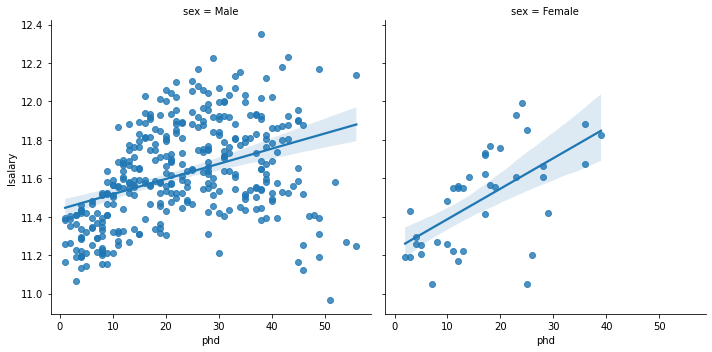

In [13]:
# несколько графиков для подвыборок
# в col – показатель группировки

sns.lmplot(data = dat, x = "phd", y = "lsalary", col ="sex");

Что мы тут видим? Значение константы в парной модели на подвыборке женщин ниже – заработная плата у женщин, в среднем, ниже, чем у мужчин. Однако при этом угол наклона в модели на этой подвыборке больше – увеличение числа лет после получения степени более сильно сказывается на заработной плате у женщин, чем у мужчин. Другими словами, эффект фактора `phd` в двух группах неодинаковый, и хорошо бы это учесть. Для наглядности уберем пока квадратичный элемент, зато добавим **эффект взаимодействия** – произведение `phd` и `sex`:

In [14]:
m04 = ols("lsalary ~ phd + phd:sex + sex + discipline", data = dat).fit()
print(m04.summary())

                            OLS Regression Results                            
Dep. Variable:                lsalary   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     35.98
Date:                Thu, 19 Jun 2025   Prob (F-statistic):           1.29e-25
Time:                        01:36:56   Log-Likelihood:                 33.769
No. Observations:                 397   AIC:                            -57.54
Df Residuals:                     392   BIC:                            -37.62
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          11.1401      0.072    1

**NB.** Если добавляем эффект взаимодействия, исходные переменные, которые входят в эффект (произведение), тоже обязательно должны включаться в модель, иначе она не имеет смысла.

Если смотреть только на значимость – можем согласиться, что хотя бы на 10% уровне значимости, коэффициент при эффекте взаимодействия все-таки значим, отличия в эффекте `phd` у мужчин и женщин есть.

Запишем уравнение такой модели:

$$
\widehat{lprice} = 11.14 + 0.19 \cdot \text{sex[T.Male]} + 0.14 \cdot \text{discipline[T.B]} + 0.02 \cdot \text{phd} - 0.01 \cdot \text{phd:sex[T.Male]}
$$

Найдем предельный эффект переменной `phd` на `lsalary` – частную производную по `phd` от функции выше:

$$
\text{marginal effect} = 0.02 - 0.01 \cdot \text{Male}
$$

Получается, эффект числа лет с момента получения степени у мужчин (`Male = 1`)  ниже на 0.01, чем у женщин. А это и есть коэффициент при переменной взаимодействия `phd:sex[T.Male]`.

Предельные эффекты можно формировать и для двух количественных переменных тоже (перемножить можно что угодно), просто тогда без вычисления предельных эффектов в конкретных точках интерпретировать это будет сложнее.